In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from __future__ import annotations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

try:
    from matplotlib_venn import venn3
    VENN_AVAILABLE = True
except ImportError:
    VENN_AVAILABLE = False
    print("matplotlib-venn non installé (pip install matplotlib-venn) -> diagramme de Venn indisponible")
 
sns.set_style("whitegrid")
 
RANDOM_STATE = 42

In [2]:
import sys
!{sys.executable} -m pip install matplotlib-venn

Calcul de l'IQR 

In [3]:
 df = pd.read_csv(r"C:\Users\kalin\OneDrive\Documents\SAFT\Data\df_sans_na.csv")  


In [4]:
def detect_anomalies_iqr(series: pd.Series, k: float = 1.5) -> pd.DataFrame:
    """
    Anomalie si le point est en dehors de [Q1 - k*IQR ; Q3 + k*IQR].
    k=1.5 = convention classique (boîte à moustaches) ; k=3 pour ne garder
    que les anomalies extrêmes.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr

    is_anomaly = ((series < lower_bound) | (series > upper_bound)).astype(int)

    distance = np.where(
        series < lower_bound,
        lower_bound - series,
        np.where(series > upper_bound, series - upper_bound, 0),
    )
    iqr_score = distance / iqr if iqr != 0 else distance

    return pd.DataFrame(
        {
            "battery_impedance_mean": series,
            "iqr_score": iqr_score,
            "is_anomaly_iqr": is_anomaly,
        }
    )



In [5]:
result = detect_anomalies_iqr(df["battery_impedance_mean"], k=1.5)

print("Bornes IQR :")
q1 = df["battery_impedance_mean"].quantile(0.25)
q3 = df["battery_impedance_mean"].quantile(0.75)
iqr = q3 - q1
print(f"  Q1 = {q1:.4f} | Q3 = {q3:.4f} | IQR = {iqr:.4f}")
print(f"  Borne basse = {q1 - 1.5 * iqr:.4f} | Borne haute = {q3 + 1.5 * iqr:.4f}")

print(f"\nAnomalies détectées : {result['is_anomaly_iqr'].sum()} / {len(result)}")
print(result[result["is_anomaly_iqr"] == 1].head(10))

Bornes IQR :
  Q1 = 0.2002 | Q3 = 0.2177 | IQR = 0.0175
  Borne basse = 0.1739 | Borne haute = 0.2440

Anomalies détectées : 11 / 887
     battery_impedance_mean  iqr_score  is_anomaly_iqr
279                0.251917   0.449322               1
559                0.389564   8.296742               1
561                0.314033   3.990610               1
563                0.454833  12.017822               1
565                0.255589   0.658612               1
567                0.438072  11.062283               1
569                0.348506   5.955948               1
571                0.603621  20.500470               1
573                0.520789  15.778085               1
575                0.341667   5.566058               1


In [6]:
result

,battery_impedance_mean,iqr_score,is_anomaly_iqr
0,0.208950,0.0,0
1,0.214772,0.0,0
2,0.208716,0.0,0
3,0.212947,0.0,0
4,0.209258,0.0,0
...,...,...,...
882,0.202921,0.0,0
883,0.198595,0.0,0
884,0.198689,0.0,0
885,0.201284,0.0,0


Illustration de l'IQR 

In [7]:
def plot_iqr_anomalies(result_iqr: pd.DataFrame, value_col: str = "battery_impedance_mean"):
    """
    Deux vues complémentaires :
    - boxplot classique (montre visuellement les bornes IQR)
    - scatter le long de l'index avec les anomalies surlignées en rouge
    """
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # Boxplot
    sns.boxplot(y=result_iqr[value_col], ax=axes[0], color="lightblue")
    axes[0].set_title("Distribution et bornes IQR")
    axes[0].axhline(lower_bound, color="red", linestyle="--", label="Bornes IQR")
    axes[0].axhline(upper_bound, color="red", linestyle="--")
    axes[0].legend()
 
    # Scatter avec anomalies surlignées
    normal = result_iqr[result_iqr["is_anomaly_iqr"] == 0]
    anomalies = result_iqr[result_iqr["is_anomaly_iqr"] == 1]
 
    axes[1].scatter(normal.index, normal[value_col], c="steelblue", label="Normal", alpha=0.6, s=15)
    axes[1].scatter(anomalies.index, anomalies[value_col], c="red", label="Anomalie", s=40, edgecolors="black")
    axes[1].axhline(lower_bound, color="red", linestyle="--", alpha=0.5)
    axes[1].axhline(upper_bound, color="red", linestyle="--", alpha=0.5)
    axes[1].set_title(f"Anomalies IQR détectées : {len(anomalies)} / {len(result_iqr)}")
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel(value_col)
    axes[1].legend()
 
    plt.tight_layout()
    plt.show()

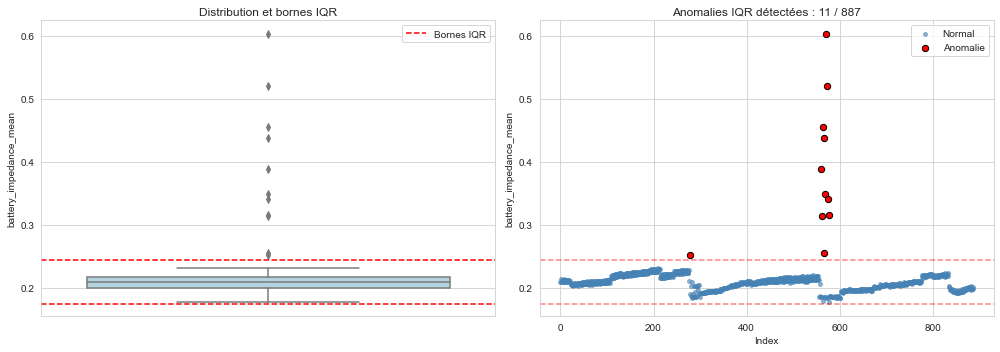

In [8]:
plot_iqr_anomalies(result, "battery_impedance_mean")

Identification d'anomalies avec Isolation forest

In [9]:

def detect_anomalies_isolation_forest(
    df: pd.DataFrame, feature_cols: list[str], contamination: float = "auto"
) -> pd.DataFrame:
    """
    - feature_cols : liste des colonnes à utiliser (1 seule colonne = univarié,
      plusieurs = multivarié / contextuel)
    - contamination : proportion attendue d'anomalies dans les données (à ajuster
      selon ta connaissance du métier, ex: 0.02 à 0.1 en général)
    """
    X = df[feature_cols].dropna()
 
    # Le scaling est indispensable : Isolation Forest découpe l'espace au hasard
    # sur les valeurs des features, donc des échelles différentes biaisent les splits
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
 
    model = IsolationForest(
        n_estimators=200,
        max_samples="auto",
        contamination=contamination,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_scaled)
 
    raw_scores = model.decision_function(X_scaled)  # plus haut = plus normal
    predictions = model.predict(X_scaled)  # -1 = anomalie, 1 = normal
 
    # Normalisation du score entre 0 et 1 (1 = anomalie forte) -> pratique pour Streamlit
    anomaly_score = (raw_scores.max() - raw_scores) / (raw_scores.max() - raw_scores.min())
 
    result = X.copy()
    result["isoforest_score"] = anomaly_score
    result["is_anomaly_isoforest"] = (predictions == -1).astype(int)
 
    return result, model

Version univariée (impédance seule)

In [10]:
    result_uni, model_uni = detect_anomalies_isolation_forest(
        df, feature_cols=["battery_impedance_mean"], contamination="auto"
    )
    print("Anomalies détectées (univarié) :", result_uni["is_anomaly_isoforest"].sum())
    print(result_uni[result_uni["is_anomaly_isoforest"] == 1].head(10))

Anomalies détectées (univarié) : 89
     battery_impedance_mean  isoforest_score  is_anomaly_isoforest
183                0.227083         0.214060                     1
191                0.228438         0.333948                     1
193                0.227721         0.256499                     1
195                0.229848         0.423893                     1
197                0.229653         0.409589                     1
199                0.229374         0.383711                     1
201                0.228743         0.358369                     1
203                0.229807         0.419411                     1
205                0.229675         0.410010                     1
207                0.229299         0.384294                     1


In [11]:
def plot_isoforest_univariate(result_uni: pd.DataFrame, value_col: str = "battery_impedance_mean"):
    """
    Scatter le long de l'index, coloré en continu par le score d'anomalie
    (plus foncé/rouge = score élevé), avec les anomalies flaggées en évidence.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # Nuage de points coloré par score continu
    scatter = axes[0].scatter(
        result_uni.index,
        result_uni[value_col],
        c=result_uni["isoforest_score"],
        cmap="RdYlBu_r",
        s=20,
    )
    axes[0].set_title("Score d'anomalie Isolation Forest (univarié)")
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel(value_col)
    plt.colorbar(scatter, ax=axes[0], label="Anomaly score")
 
    # Anomalies binaires surlignées
    normal = result_uni[result_uni["is_anomaly_isoforest"] == 0]
    anomalies = result_uni[result_uni["is_anomaly_isoforest"] == 1]
 
    axes[1].scatter(normal.index, normal[value_col], c="steelblue", label="Normal", alpha=0.6, s=15)
    axes[1].scatter(anomalies.index, anomalies[value_col], c="red", label="Anomalie", s=40, edgecolors="black")
    axes[1].set_title(f"Anomalies détectées : {len(anomalies)} / {len(result_uni)}")
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel(value_col)
    axes[1].legend()
 
    plt.tight_layout()
    plt.show()

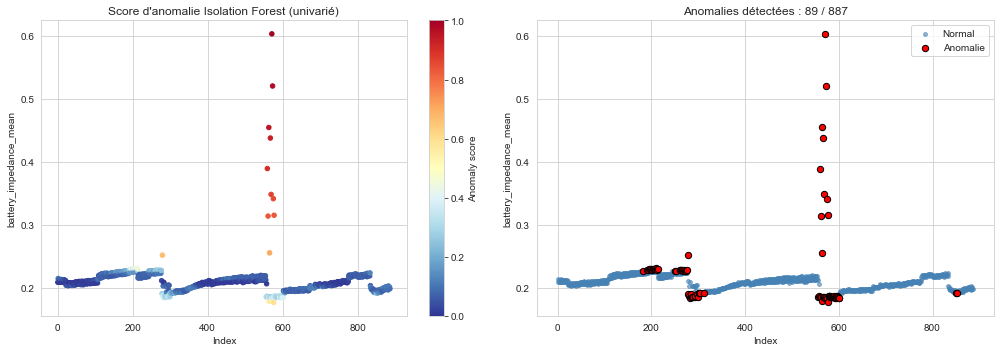

In [12]:
plot_isoforest_univariate(result_uni,"battery_impedance_mean")

Version multivariée (impédance + autres variables numériques disponibles) 

In [13]:
 # Sélectionne automatiquement les colonnes numériques du dataset
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nColonnes numériques disponibles :", numeric_cols)
 
# Adapte cette liste selon les variables pertinentes de ton dataset
# (ex: température, tension, courant, cycle...)
feature_cols_multi = [c for c in numeric_cols if c != "id"]  # à ajuster
 
result_multi, model_multi = detect_anomalies_isolation_forest(
df, feature_cols=feature_cols_multi, contamination="auto"
)
print("\nAnomalies détectées (multivarié) :", result_multi["is_anomaly_isoforest"].sum())
print(result_multi[result_multi["is_anomaly_isoforest"] == 1].head(10))
 
    # result_uni et result_multi sont directement exploitables dans Streamlit :
    # - st.slider sur contamination ou sur isoforest_score
    # - st.selectbox pour choisir les colonnes à inclure dans la version multivariée
    # - scatter plot (battery_impedance_mean en x, score en y) avec points anormaux surlignés


Colonnes numériques disponibles : ['cycle_index', 'ambient_temperature', 'sense_current_mean', 'battery_current_mean', 'current_ratio_mean', 'battery_impedance_mean', 'Re', 'Rct']

Anomalies détectées (multivarié) : 161
   cycle_index  ambient_temperature  sense_current_mean  battery_current_mean  \
0           40                   24          816.426702            323.103983   
1           42                   24          815.031926            323.625633   
2           44                   24          815.760720            323.740165   
3           46                   24          814.673681            324.426346   
4           48                   24          816.246188            323.067471   
5           50                   24          813.800225            325.450053   
6           52                   24          816.210639            323.217859   
7           54                   24          814.473522            324.676052   
8           56                   24          816.2

In [14]:

def plot_isoforest_multivariate(result_multi: pd.DataFrame, feature_cols: list):
    """
    Le multivarié ne peut pas se visualiser directement au-delà de 2-3 dimensions.
    On projette les features en 2D avec une PCA pour visualiser la séparation
    normal / anomalie dans un espace réduit.
    """
    X = result_multi[feature_cols]
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
 
    result_plot = result_multi.copy()
    result_plot["pca_x"] = coords[:, 0]
    result_plot["pca_y"] = coords[:, 1]
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # Coloré par score continu
    scatter = axes[0].scatter(
        result_plot["pca_x"],
        result_plot["pca_y"],
        c=result_plot["isoforest_score"],
        cmap="RdYlBu_r",
        s=20,
    )
    axes[0].set_title("Score d'anomalie Isolation Forest (multivarié, projection PCA)")
    axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
    axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
    plt.colorbar(scatter, ax=axes[0], label="Anomaly score")
 
    # Anomalies binaires
    normal = result_plot[result_plot["is_anomaly_isoforest"] == 0]
    anomalies = result_plot[result_plot["is_anomaly_isoforest"] == 1]
 
    axes[1].scatter(normal["pca_x"], normal["pca_y"], c="steelblue", label="Normal", alpha=0.6, s=15)
    axes[1].scatter(anomalies["pca_x"], anomalies["pca_y"], c="red", label="Anomalie", s=40, edgecolors="black")
    axes[1].set_title(f"Anomalies détectées : {len(anomalies)} / {len(result_plot)}")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].legend()
 
    plt.tight_layout()
    plt.show()
 
    return result_plot  # utile si tu veux réutiliser pca_x / pca_y ensuite (ex: dans Streamlit)

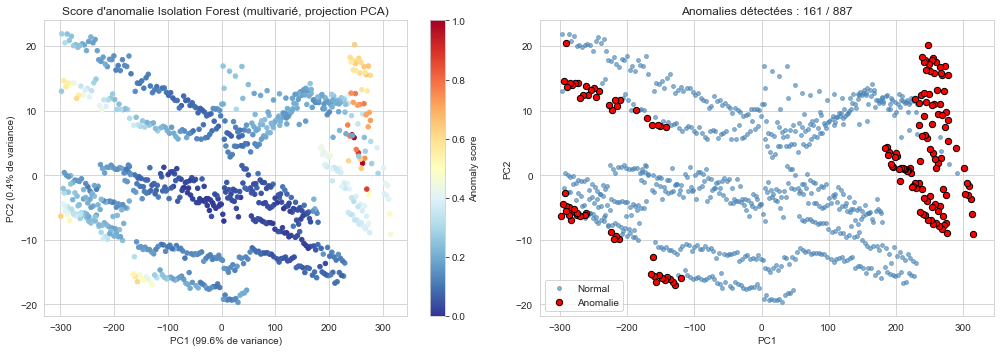

,cycle_index,ambient_temperature,sense_current_mean,battery_current_mean,current_ratio_mean,battery_impedance_mean,Re,Rct,isoforest_score,is_anomaly_isoforest,pca_x,pca_y
0,40,24,816.426702,323.103983,2.567285,0.208950,0.044669,0.069456,0.377930,1,275.934918,-8.909673
1,42,24,815.031926,323.625633,2.577993,0.214772,0.046687,0.076275,0.414192,1,274.031325,-7.438821
2,44,24,815.760720,323.740165,2.563344,0.208716,0.044843,0.067972,0.407844,1,272.003078,-7.733217
3,46,24,814.673681,324.426346,2.566611,0.212947,0.046195,0.074534,0.384759,1,270.090470,-6.357836
4,48,24,816.246188,323.067471,2.569041,0.209258,0.045101,0.068528,0.381808,1,267.959591,-8.294470
...,...,...,...,...,...,...,...,...,...,...,...,...
882,289,24,827.052272,337.659387,2.522040,0.202921,0.065169,0.095707,0.297173,0,27.510477,10.222190
883,291,24,823.755099,341.444018,2.487052,0.198595,0.063739,0.091152,0.253974,0,25.835903,15.353507
884,302,24,823.699639,341.459530,2.488731,0.198689,0.065219,0.090349,0.247728,0,14.862668,16.112810
885,312,24,825.844922,338.944406,2.508327,0.201284,0.065905,0.092010,0.264424,0,4.672752,13.465541


In [15]:
plot_isoforest_multivariate(result_multi, feature_cols_multi)

Comparaison entre les méthodes 

DIAGRAMME DE VENN — recouvrement des anomalies détectées

CONSTRUCTION DU TABLEAU CONSOLIDÉ

In [16]:
# 1. result_iqr — depuis le script IQR
result_iqr = detect_anomalies_iqr(df["battery_impedance_mean"], k=1.5)

# 2. result_uni — Isolation Forest univarié
result_uni, model_uni = detect_anomalies_isolation_forest(
    df, feature_cols=["battery_impedance_mean"], contamination="auto"
)

# 3. result_multi — Isolation Forest multivarié
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_multi = [c for c in numeric_cols if c != "id"]  # adapte selon tes colonnes

result_multi, model_multi = detect_anomalies_isolation_forest(
    df, feature_cols=feature_cols_multi, contamination="auto"
)

In [17]:
def build_comparison_table(
    result_iqr: pd.DataFrame,
    result_uni: pd.DataFrame,
    result_multi: pd.DataFrame,
    value_col: str = "battery_impedance_mean",
) -> pd.DataFrame:
    """
    Fusionne les trois résultats sur l'index commun. Suppose que les trois
    DataFrames partagent le même index d'origine (même dataset de départ).
    """
    comparison = pd.DataFrame(index=result_iqr.index)
    comparison[value_col] = result_iqr[value_col]
 
    comparison["iqr_score"] = result_iqr["iqr_score"]
    comparison["anomaly_iqr"] = result_iqr["is_anomaly_iqr"]
 
    comparison["isoforest_uni_score"] = result_uni["isoforest_score"].reindex(comparison.index)
    comparison["anomaly_isoforest_uni"] = result_uni["is_anomaly_isoforest"].reindex(comparison.index)
 
    comparison["isoforest_multi_score"] = result_multi["isoforest_score"].reindex(comparison.index)
    comparison["anomaly_isoforest_multi"] = result_multi["is_anomaly_isoforest"].reindex(comparison.index)
 
    # Remplace les NaN (points exclus par dropna dans une des méthodes) par 0
    anomaly_cols = ["anomaly_iqr", "anomaly_isoforest_uni", "anomaly_isoforest_multi"]
    comparison[anomaly_cols] = comparison[anomaly_cols].fillna(0).astype(int)
 
    comparison["n_methods_flagged"] = comparison[anomaly_cols].sum(axis=1)
 
    return comparison

In [18]:
comparison = build_comparison_table(result_iqr, result_uni, result_multi)

In [19]:
def plot_venn_diagram(comparison: pd.DataFrame) -> None:
    """Visualise combien de points sont détectés par une, deux ou trois méthodes."""
    if not VENN_AVAILABLE:
        print("Installe matplotlib-venn pour ce graphique : pip install matplotlib-venn")
        return
 
    set_iqr = set(comparison[comparison["anomaly_iqr"] == 1].index)
    set_uni = set(comparison[comparison["anomaly_isoforest_uni"] == 1].index)
    set_multi = set(comparison[comparison["anomaly_isoforest_multi"] == 1].index)
 
    plt.figure(figsize=(7, 7))
    venn3(
        [set_iqr, set_uni, set_multi],
        set_labels=("IQR univarié", "IsoForest univarié", "IsoForest multivarié"),
    )
    plt.title("Recouvrement des anomalies détectées par méthode")
    plt.show()

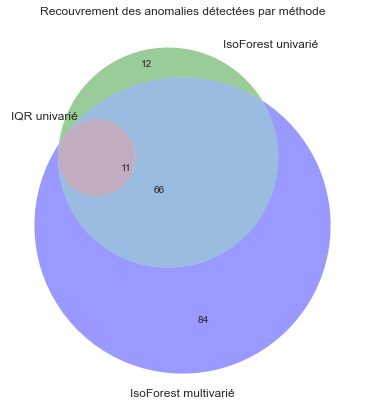

In [20]:
plot_venn_diagram(comparison)

In [ ]:
Scatter agreement methods

In [22]:
"""
Scatter plot : battery_impedance_mean coloré selon le nombre de méthodes
(IQR, Isolation Forest univarié, Isolation Forest multivarié) qui flaggent
chaque point comme anomalie.
 
Suppose que `comparison` a déjà été construit avec build_comparison_table()
et contient les colonnes : battery_impedance_mean, n_methods_flagged.
"""
 
import matplotlib.pyplot as plt
 
 
def plot_methods_agreement_scatter(comparison, value_col: str = "battery_impedance_mean"):
    """
    Plus un point est foncé/rouge, plus il est détecté comme anomalie
    par un grand nombre de méthodes -> signal de confiance plus fort.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
 
    scatter = ax.scatter(
        comparison.index,
        comparison[value_col],
        c=comparison["n_methods_flagged"],
        cmap="Reds",
        s=30,
        vmin=0,
        vmax=3,
        edgecolors="grey",
        linewidths=0.3,
    )
 
    ax.set_title("Points colorés selon le nombre de méthodes en accord")
    ax.set_xlabel("Index")
    ax.set_ylabel(value_col)
 
    cbar = plt.colorbar(scatter, ax=ax, label="Nombre de méthodes flaggant le point")
    cbar.set_ticks([0, 1, 2, 3])
 
    plt.tight_layout()
    plt.show()

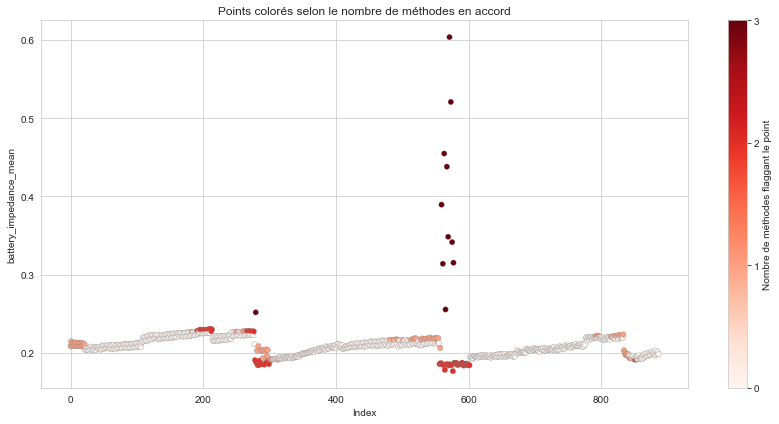

In [23]:
  plot_methods_agreement_scatter(comparison, value_col="battery_impedance_mean")